### Importing essential liabraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Loading the Data

In [2]:
df = pd.read_csv('blinkit_data.csv')

### Understanding Basic Structure

In [3]:
df.sample(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
3850,Low Fat,NCR05,Health and Hygiene,2010,OUT046,Tier 1,Small,Supermarket Type1,0.054631,10.100,200.2084,3.9
2848,Low Fat,FDX24,Baking Goods,2015,OUT045,Tier 2,Medium,Supermarket Type1,0.013957,8.355,94.0462,4.1
3134,Low Fat,FDF16,Frozen Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.085715,NaN,146.6076,4.1
793,Low Fat,FDL36,Baking Goods,2015,OUT045,Tier 2,Medium,Supermarket Type1,0.076230,15.100,90.4830,4.5
3546,reg,FDR44,Fruits and Vegetables,2015,OUT045,Tier 2,Medium,Supermarket Type1,0.103130,6.110,129.5968,4.0
1803,Regular,FDY11,Baking Goods,2000,OUT013,Tier 3,High,Supermarket Type1,0.029536,6.710,67.5142,4.3
4623,Low Fat,FDK09,Snack Foods,1998,OUT019,Tier 1,Small,Grocery Store,0.160666,NaN,227.5352,3.6
6332,Low Fat,DRE49,Soft Drinks,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.021283,20.750,153.5024,4.0
6563,Regular,FDP21,Snack Foods,1998,OUT019,Tier 1,Small,Grocery Store,0.045069,NaN,190.8872,4.0
5502,Low Fat,NCC31,Household,2000,OUT013,Tier 3,High,Supermarket Type1,0.000000,8.020,157.7972,2.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
df.nunique()

Item Fat Content                5
Item Identifier              1559
Item Type                      16
Outlet Establishment Year       9
Outlet Identifier              10
Outlet Location Type            3
Outlet Size                     3
Outlet Type                     4
Item Visibility              7880
Item Weight                   415
Sales                        5938
Rating                         39
dtype: int64

In [6]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

### Data Cleaning

In [7]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [8]:
df['Item Fat Content'] = df['Item Fat Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

In [9]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [10]:
df.columns = [i.strip().lower().replace(' ','_') for i in df.columns]
print(df.columns)

Index(['item_fat_content', 'item_identifier', 'item_type',
       'outlet_establishment_year', 'outlet_identifier',
       'outlet_location_type', 'outlet_size', 'outlet_type', 'item_visibility',
       'item_weight', 'sales', 'rating'],
      dtype='object')


In [17]:
df.drop_duplicates()

,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,item_visibility,item_weight,sales,rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,Low Fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,Low Fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,Low Fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,Regular,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


### KPI's

In [11]:
# Total Sales
total_sales = df['sales'].sum()

# Average Sales per Order
avg_sales = df['sales'].mean()

# Total Items Sold
total_items = df['item_type'].count()

# Average Ratings
avg_rating = df['rating'].mean()

# Diplay
print(f"Total Sales - ₹{total_sales:,.0f}")
print(f"Average Sales per Order - ₹{avg_sales:,.0f}")
print(f"Total Items Sold - {total_items:,}")
print(f"Average Rating - {avg_rating:.2f}")

Total Sales - ₹1,201,681
Average Sales per Order - ₹141
Total Items Sold - 8,523
Average Rating - 3.97


### Charts

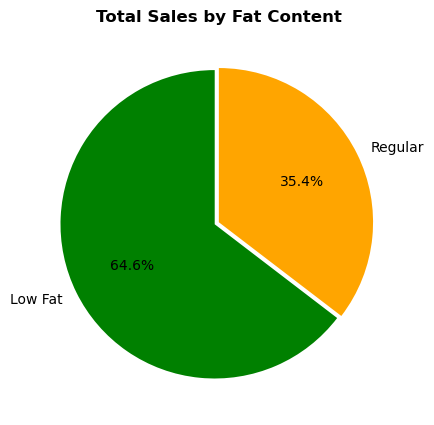

In [12]:
df.groupby('item_fat_content')['sales'].sum().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=90,
    explode=[0.03, 0],
    colors=['green','orange'],
    figsize=(4.5,4.5)
    )

plt.title('Total Sales by Fat Content', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

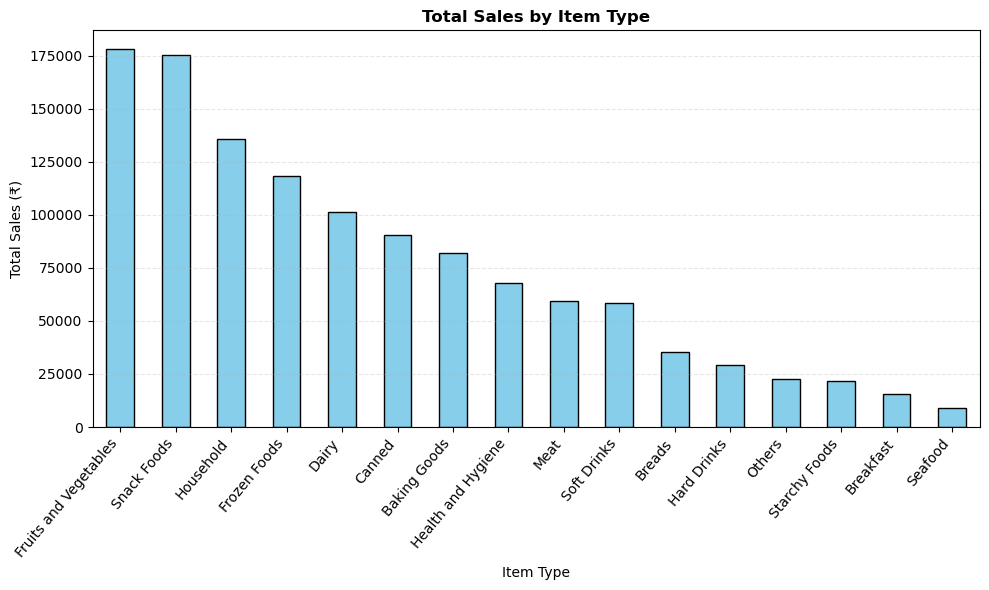

In [13]:
df.groupby('item_type')['sales'].sum().sort_values(ascending=False).plot(
    kind='bar',
    color='skyblue',
    figsize=(10, 6),
    width=0.5,
    edgecolor='black'
)

plt.title('Total Sales by Item Type', fontsize=12, fontweight='bold')
plt.xlabel('Item Type')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=50, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

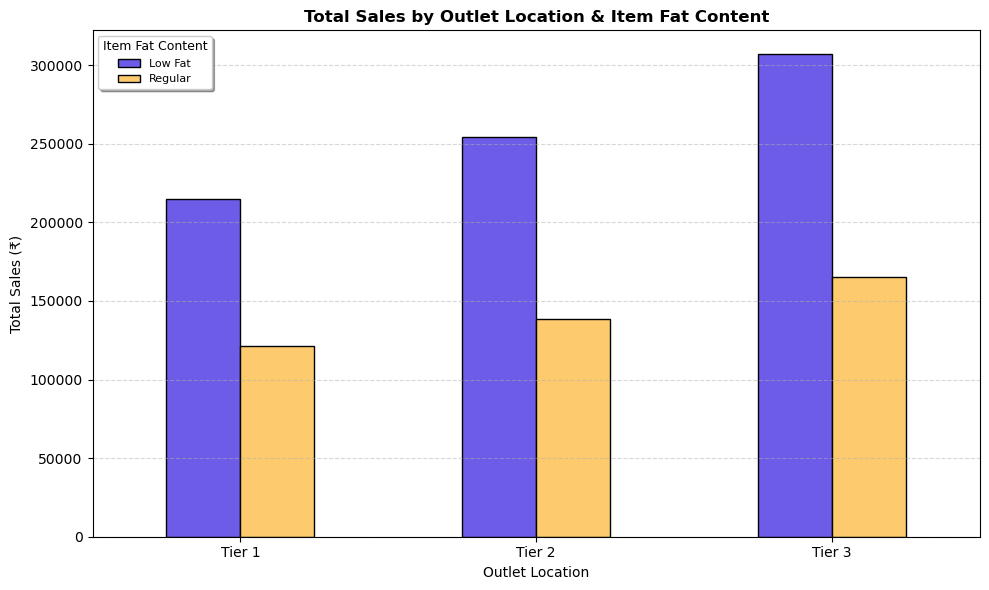

In [14]:
df.groupby(['outlet_location_type','item_fat_content'])['sales'].sum().unstack().plot(
    kind='bar',
    color=['#6c5ce7', '#fdcb6e'],
    figsize=(10, 6),
    width=0.5,
    edgecolor='black'
)

plt.title('Total Sales by Outlet Location & Item Fat Content', fontsize=12, fontweight='bold')
plt.xlabel('Outlet Location')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=0)
plt.legend(
    title='Item Fat Content',
    title_fontsize=9,
    fontsize=8,
    loc='upper left',
    frameon=True,
    shadow=True,
    facecolor='white'
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

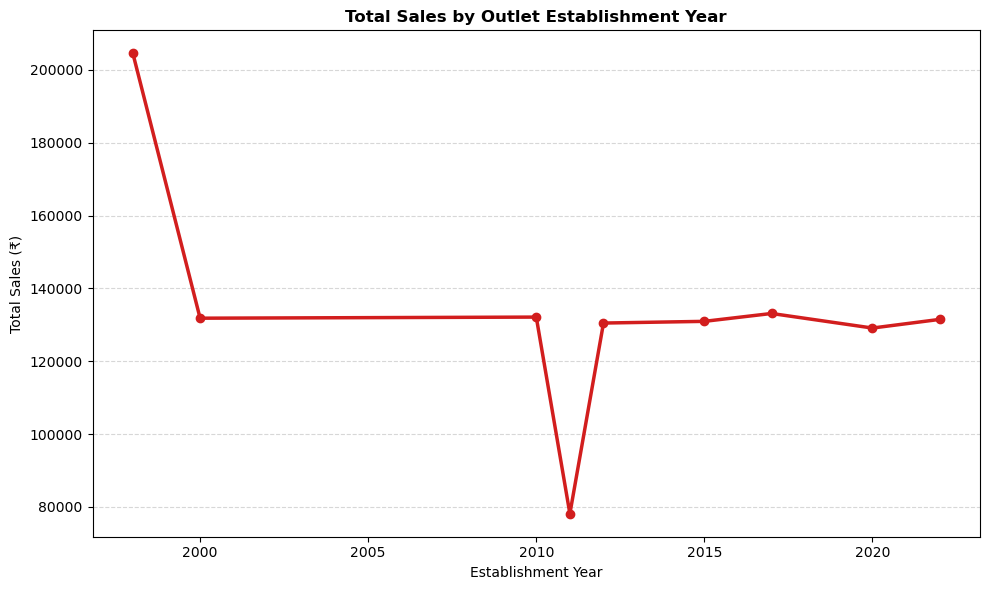

In [15]:
df.groupby('outlet_establishment_year')['sales'].sum().sort_index().plot(
    kind='line',
    color='#d21e1e',
    figsize=(10, 6),
    marker='o',
    linewidth=2.5
)

plt.title('Total Sales by Outlet Establishment Year', fontsize=12, fontweight='bold')
plt.xlabel('Establishment Year')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

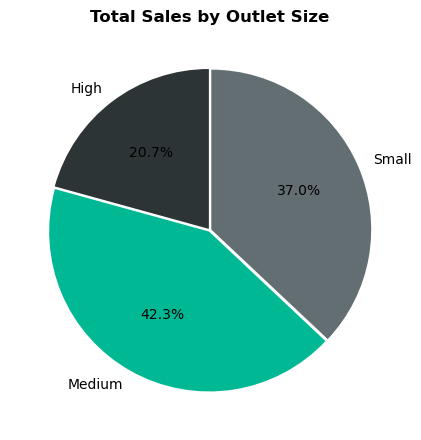

In [16]:
df.groupby('outlet_size')['sales'].sum().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    startangle=90,
    explode=[0.01, 0.01, 0.01],
    colors=['#2d3436', '#00b894', '#636e72'],
    figsize=(4.5, 4.5)
)

plt.title('Total Sales by Outlet Size', fontsize=12, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()